In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

# torch.manual_seed(0)
# torch.cuda.manual_seed(0)

# global_path = "/home/ids/edabier/HSU"
global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import losses
from src.utils import plots
from src.utils import extractor
from src.models import models
from src.models import foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
dataset = "jasper"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
# Y_init = Y_init/Y_init.max()
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

features: torch.Size([1024, 196])
tensor(5388.8291, device='cuda:0', grad_fn=<MeanBackward0>)


9.889568

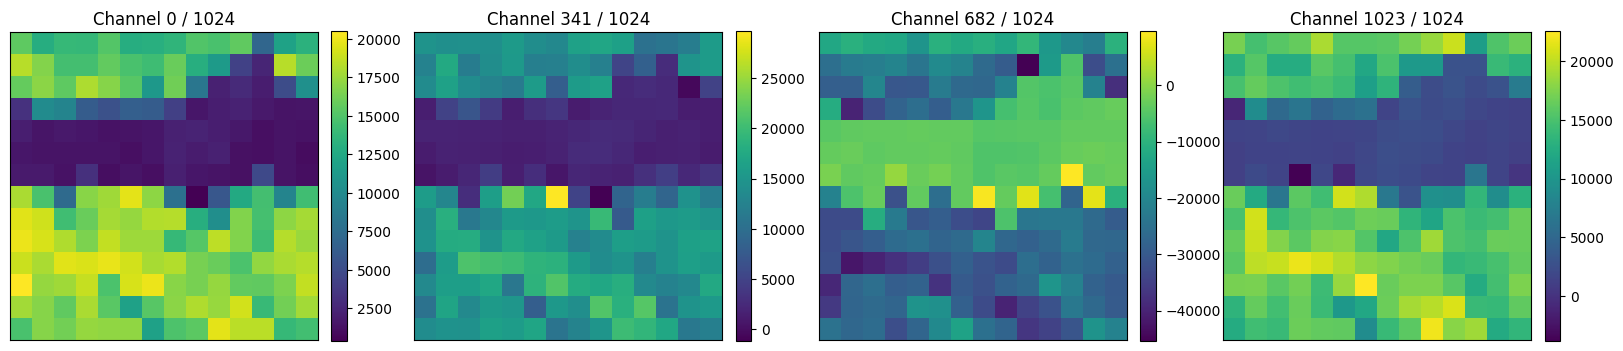

In [ ]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init_f, new_H, wavelengths)
D = int(features.shape[0]/1)
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")

plots.plot_hsi(features.reshape(D, alpha, alpha), 4)
print(features.mean())

unmixer = rsfm.Unmixing_from_features(D=D, H=new_H, alpha=alpha, B=B, c=c)
sum(p.numel() for p in unmixer.parameters() if p.requires_grad)/1e6

In [ ]:
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
epochs, lr = 200, 0.002

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

n_xp = 3
mses, sads = [], []
mses_in, sads_in = [], []
torch.autograd.set_detect_anomaly(True)

E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
# upsampled_features = torch.zeros(n_xp, D, new_H, new_H)
upsampled_abundances = torch.zeros(n_xp, c, new_H, new_H)
lr_abundances = torch.zeros(n_xp, c, alpha, alpha)

for n in range(n_xp):

    model = rsfm.Unmixing_from_features0(D=D, alpha=alpha, H=new_H, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, is_unmixer=True)

    model = model.to(dev)
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for epoch in range(epochs):
        
        for Y, E, A in loader:
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            
            Y_up, features = rsfm.extract_f(fm, Y, new_H, wavelengths)

            E_hat, A_hat, Y_hat, A_hat_lr = model(features)
            Y_hat_lr = model.decoder(A_hat_lr)

            loss = model.loss(Y_up, Y_hat, A_hat, E_hat, alpha, Y_hat_lr)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()

            if hasattr(model, 'decoder'):
                with torch.no_grad():
                    constraints = models.weightConstraint()
                    model.decoder.apply(constraints)

            del loss, Y, E, A, features, E_hat, A_hat, Y_hat, constraints
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            gc.collect()
        
    model.eval()
    with torch.no_grad():
        _, A, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths, A_init)
        E_hat, A_hat, _, A_hat_lr = model(features)
        # up_features = model.upsample(features)
        # upsampled_features[n] = utils.oneD_to_2d(up_features)
        upsampled_abundances[n] = A_hat
        lr_abundances[n] = A_hat_lr
        # if xp == 1:    
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
        sads.append(sad)
        mses.append(mse)

    E_hats[n] = E_hat
    A_hats[n] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)

sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A, E_init, normalize_E=True, normalize_A=True, return_results=True)#, plot_A=False, plot_E=False)
print(f"SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


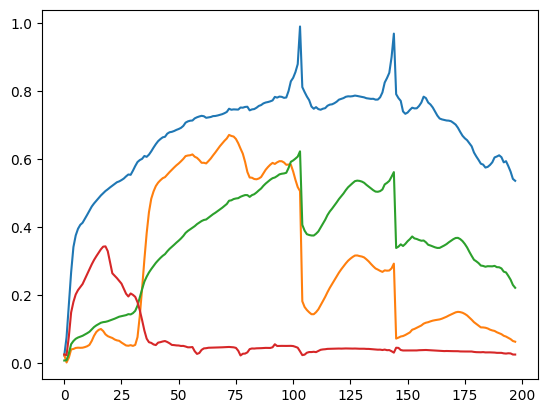

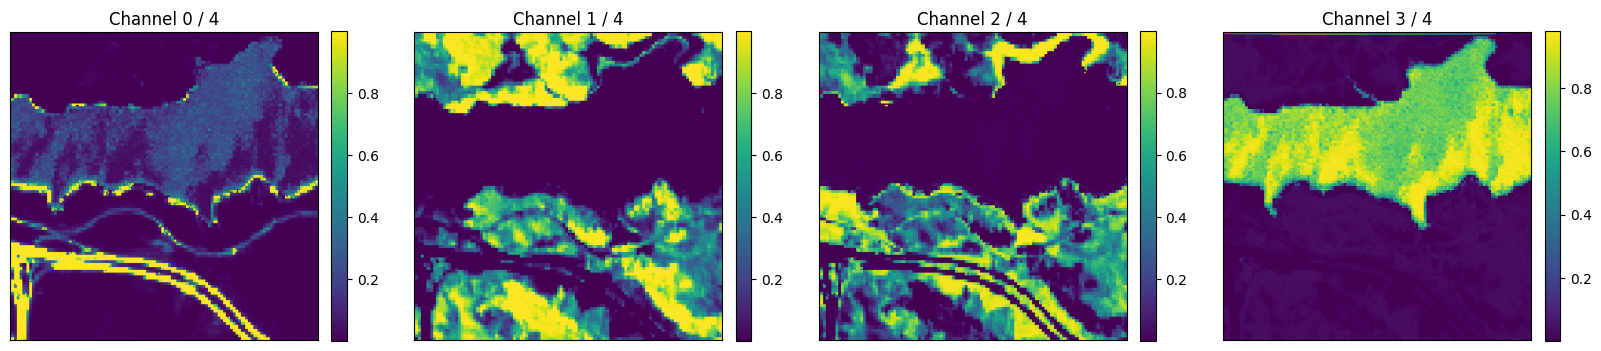

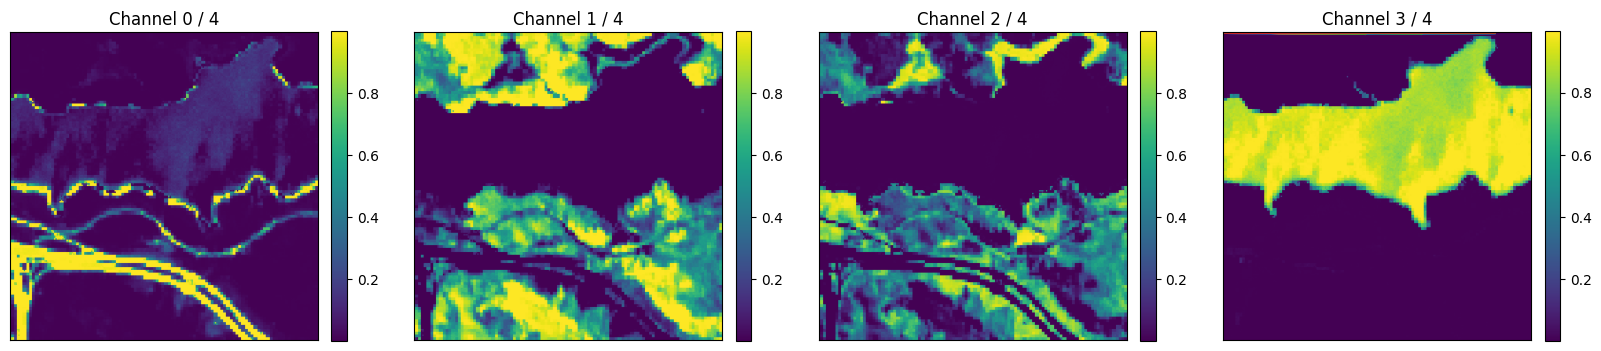

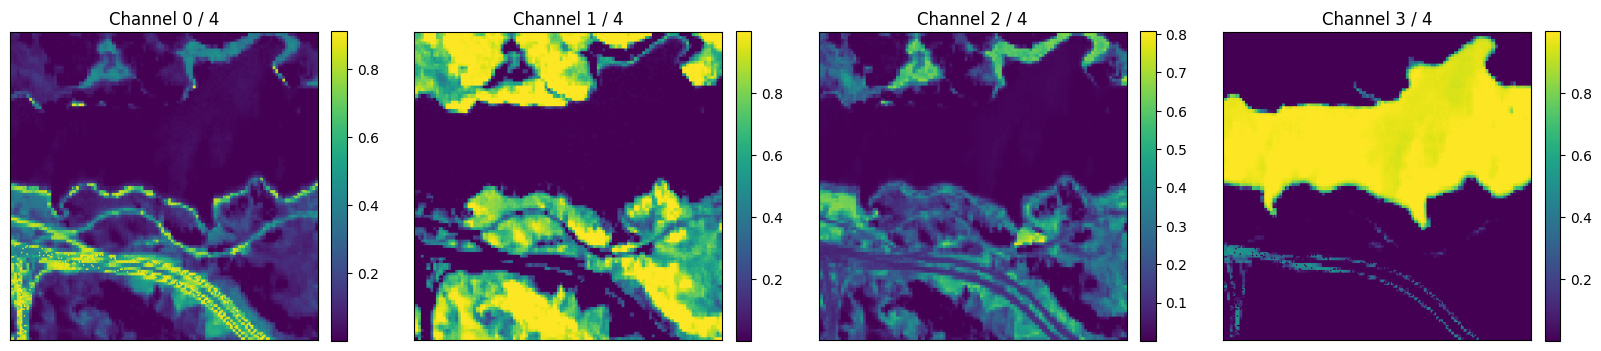

In [14]:
for i in range(n_xp):
    plt.plot(E_hats[i][:,:].detach().cpu())
    plots.plot_hsi(A_hats[i])
    # plt.show()

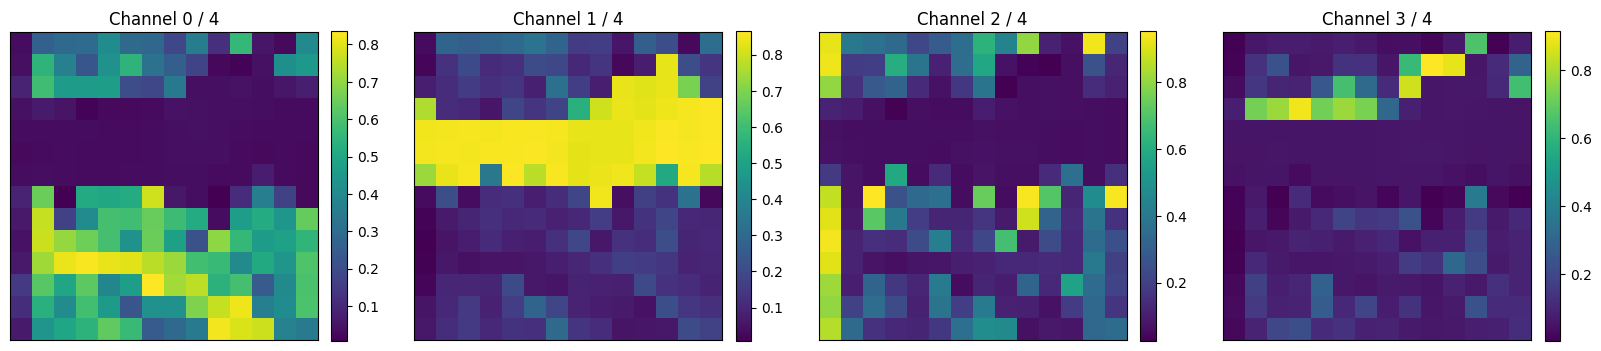

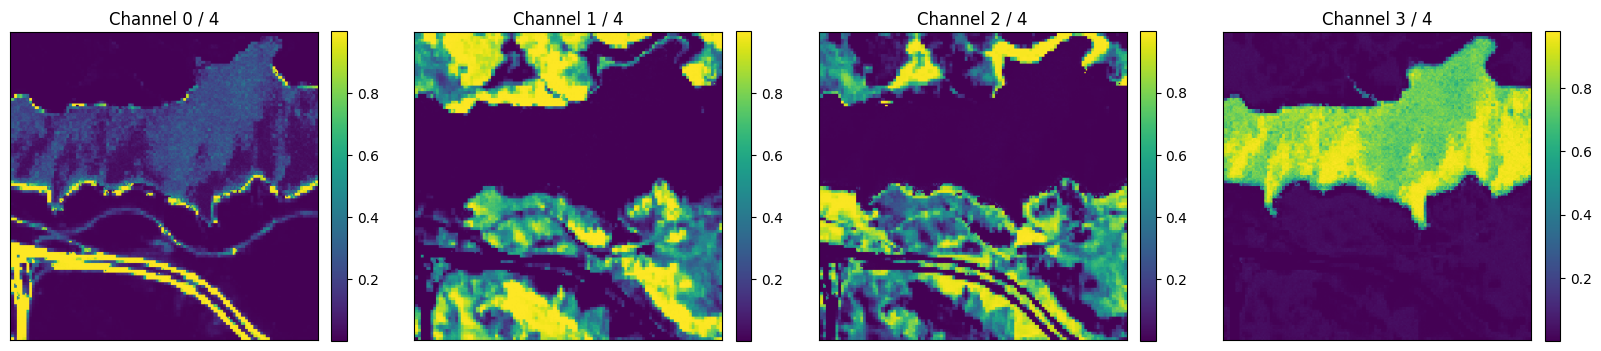

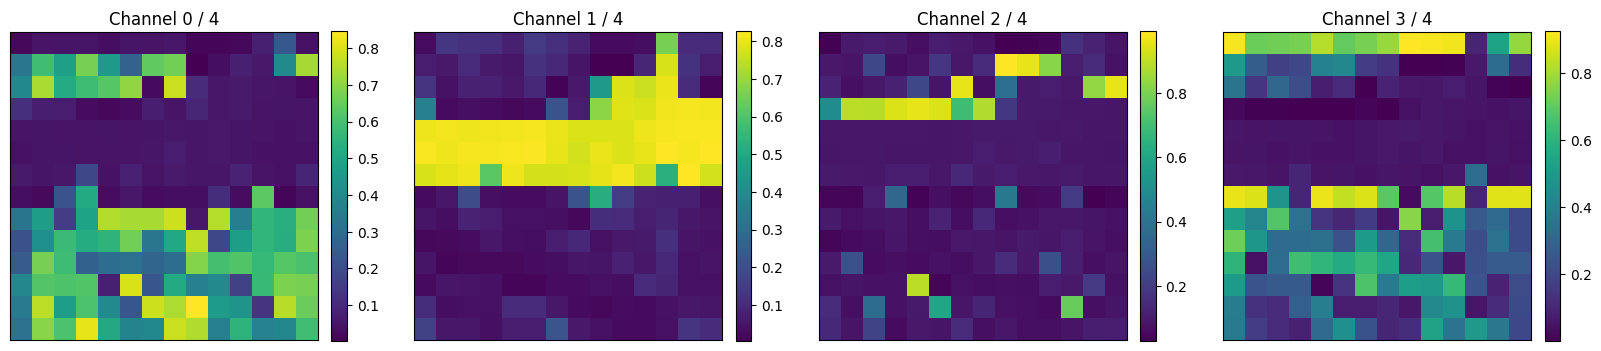

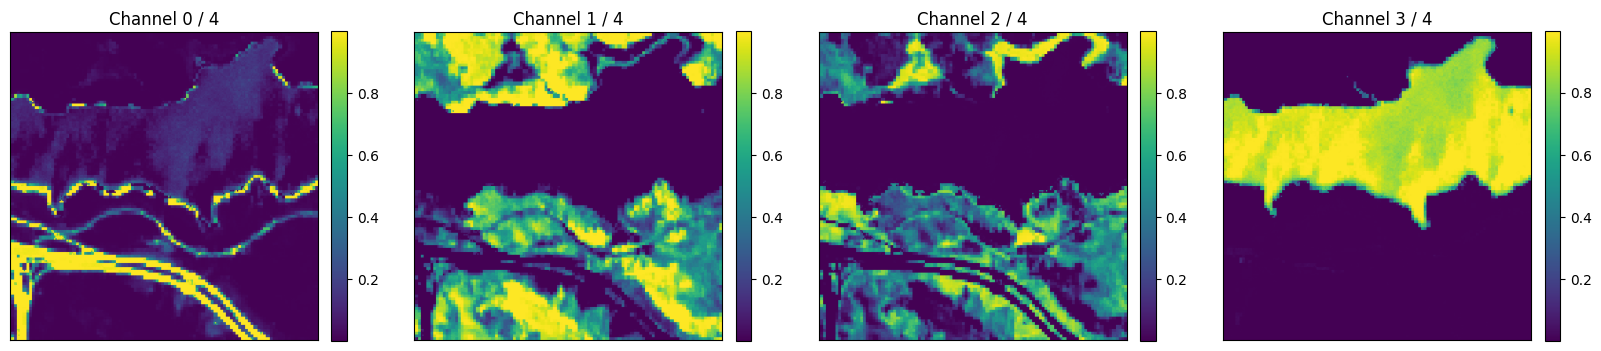

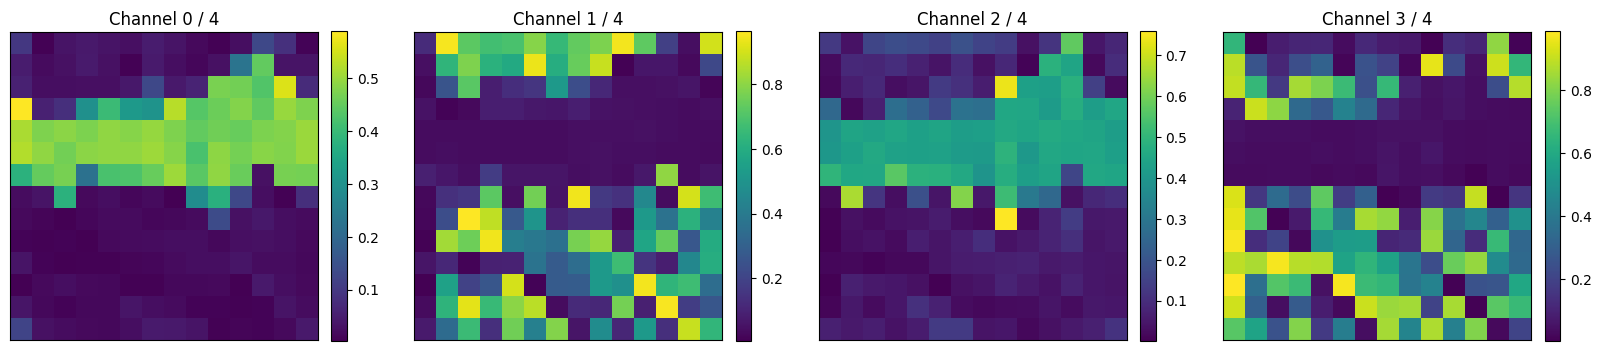

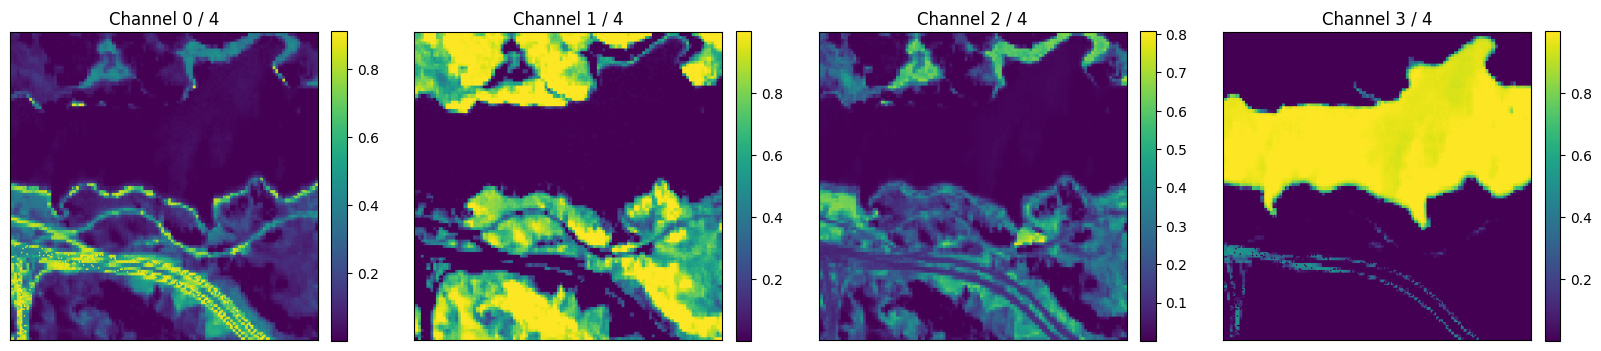

In [5]:
for i in range(n_xp):
    plots.plot_hsi(lr_abundances[i])
    plots.plot_hsi(upsampled_abundances[i])

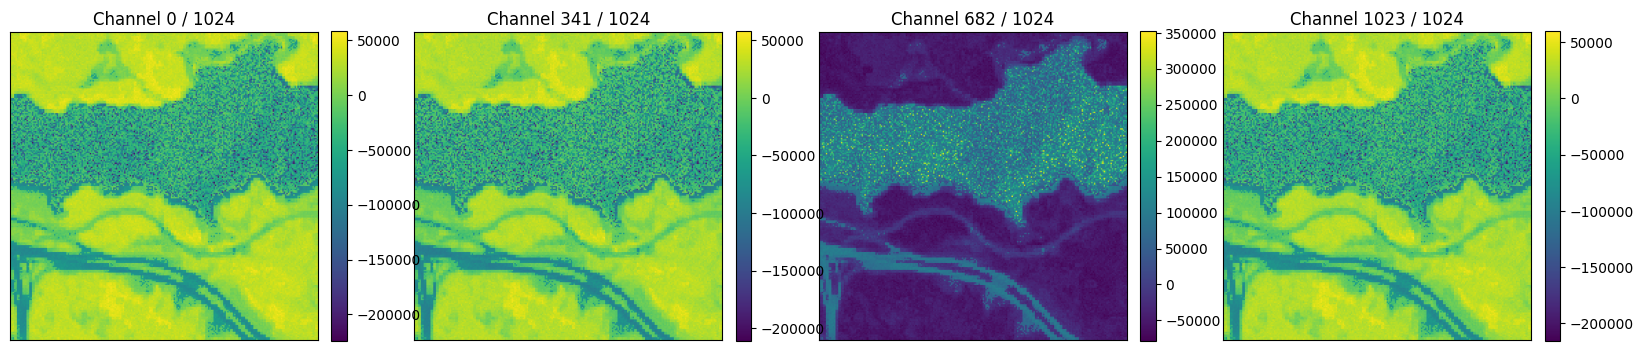

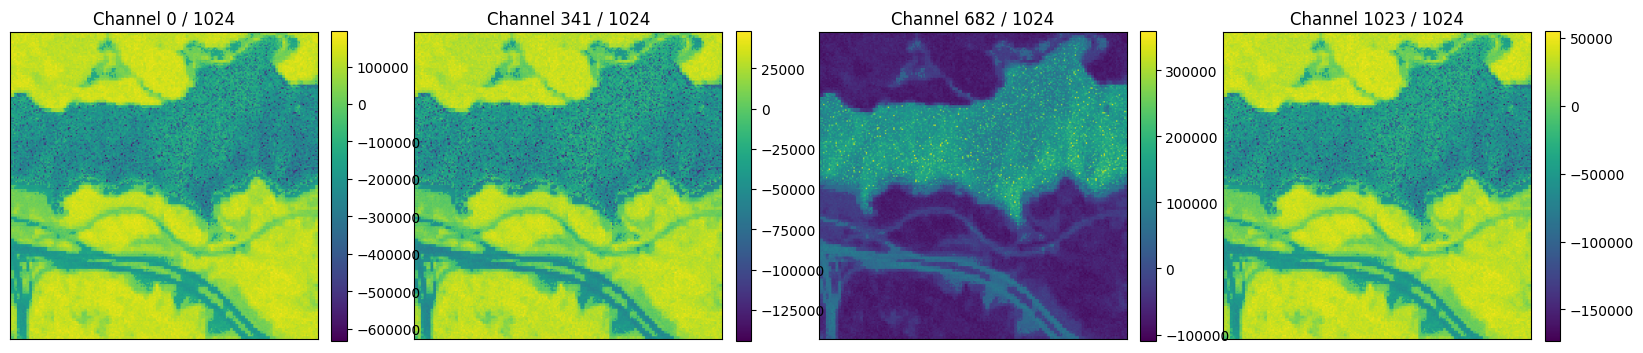

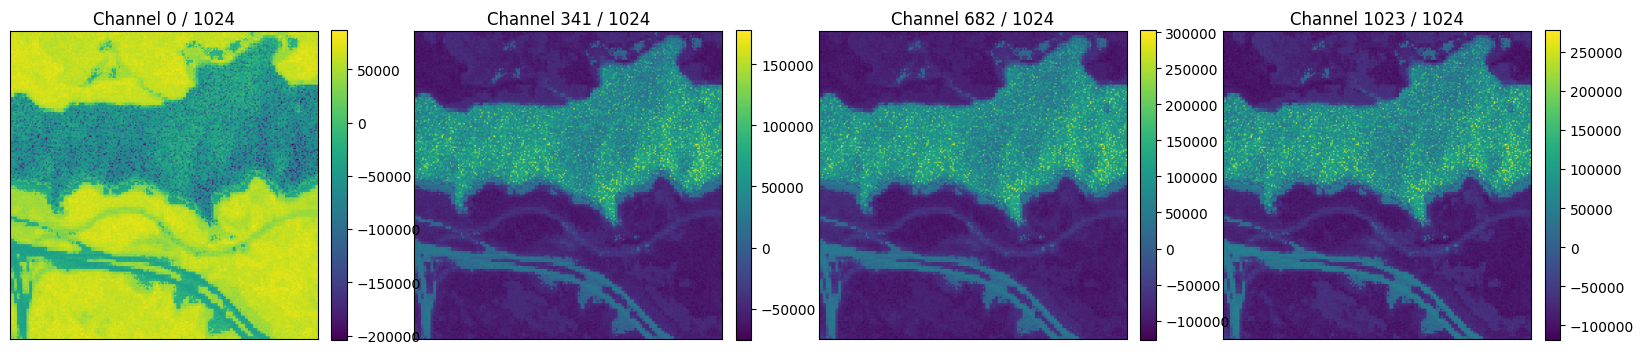

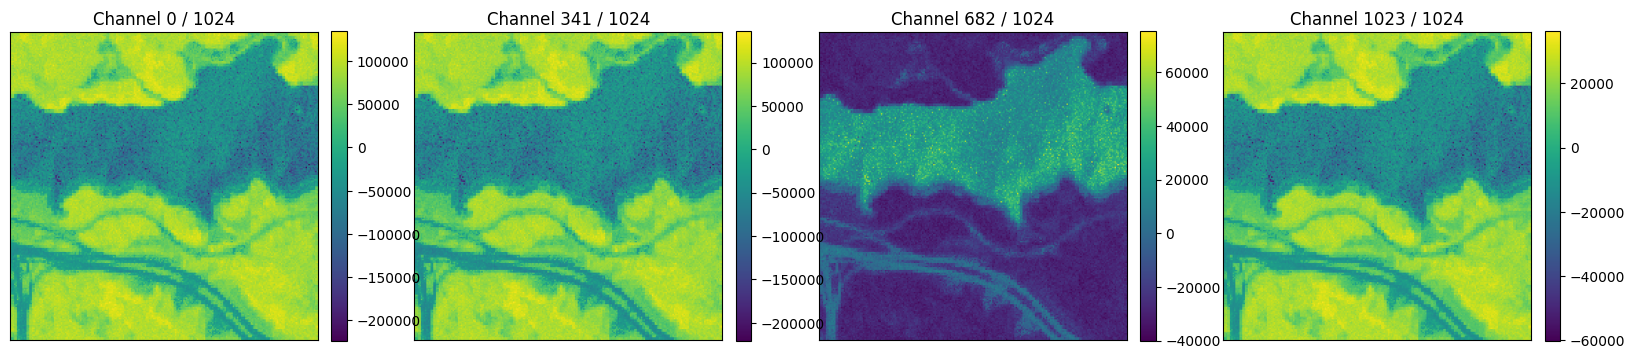

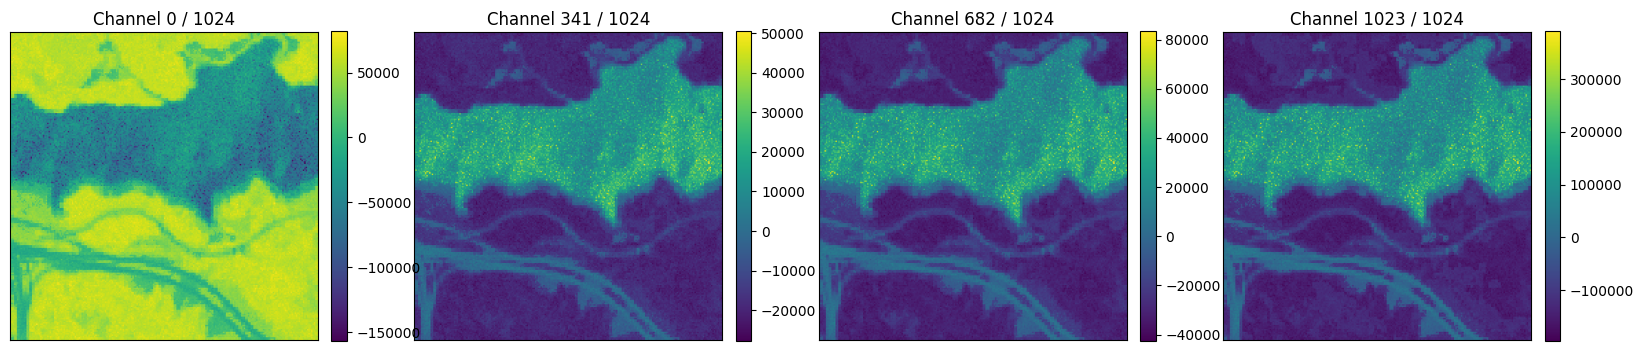

In [21]:
ref = upsampled_features[0]
reordered_features = torch.zeros_like(upsampled_features)
reordered_features[0] = ref
    
for i in range(n_xp-1):
    up_feat, _ = utils.order_endmembers(ref.flatten(1), upsampled_features[i+1].flatten(1))
    reordered_features[i+1] = utils.oneD_to_2d(up_feat)
# plots.plot_hsi(ref, 4)
# plots.plot_hsi(up_feat, 4)
for i in range(n_xp):
    plots.plot_hsi(reordered_features[i], 4)

In [6]:
# _, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)
# feat_up = utils.oneD_to_2d(model.upsample(features))
# features = utils.oneD_to_2d(features)
# downsample = nn.AdaptiveAvgPool2d(features[0].shape)
# feat_down = downsample(feat_up)
# feat_down.shape

In [7]:
# i = 100

# up1 = upsampled_features[0][i]
# up2 = upsampled_features[1][i]

# fig, axs = plt.subplots(1, 2, figsize=(10,10))

# im1 = axs[0].imshow(torch.gradient(up1)[1].detach().cpu())
# axs[0].set_xticks([])
# axs[0].set_yticks([])
# plt.colorbar(im1, fraction=0.046, pad=0.04)

# im2 = axs[1].imshow(torch.gradient(up2)[1].detach().cpu())
# axs[1].set_xticks([])
# axs[1].set_yticks([])
# plt.colorbar(im2, fraction=0.046, pad=0.04)

In [17]:
mse_loss = nn.MSELoss()

E_hat_2, A_hat_m_2, _ = utils.order_endmembers(E_init, E_hat_m, A_hat_m)
rmse = torch.sqrt(mse_loss(A_init, A_hat_m_2))
rmse

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/torch/utils/_device.py:103: UserWarning: Using a target size (torch.Size([3, 95, 95])) that is different to the input size (torch.Size([1, 3, 95, 95])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)


tensor(0.1635, device='cuda:0')